# 🌸 Week 3 – Clustering & Dimensionality Reduction

### Machine Learning & AI Internship

---

## Objectives

This notebook demonstrates:

- K-Means Clustering on the Iris dataset
- Cluster Visualization
- Principal Component Analysis (PCA)
- Explained Variance Ratio
- Comparison of Predicted Clusters with True Labels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

## Load the Iris Dataset

In [4]:
iris_df = pd.read_csv("Iris.csv")

print("Dataset Loaded Successfully!")


Dataset Loaded Successfully!


In [5]:
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
iris_df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [8]:
iris_df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


## Data Preprocessing

In [9]:
label_encoder = LabelEncoder()

iris_df["Species"] = label_encoder.fit_transform(iris_df["Species"])

iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [10]:
X = iris_df.drop(["Id", "Species"], axis=1)

y = iris_df["Species"]

## Assignment 1 – Apply K-Means Clustering

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X)

clusters = kmeans.labels_

In [12]:
print("Cluster Centers:\n")

print(kmeans.cluster_centers_)

Cluster Centers:

[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.418      1.464      0.244     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


## Visualize Clusters

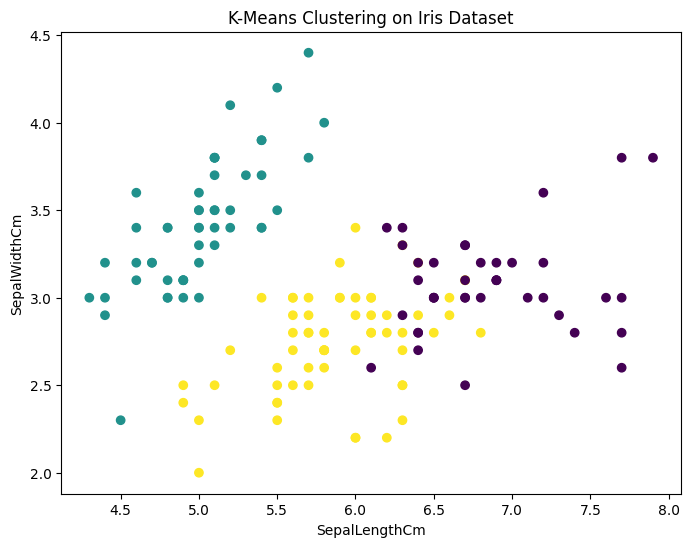

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=clusters
)

plt.xlabel(X.columns[0])

plt.ylabel(X.columns[1])

plt.title("K-Means Clustering on Iris Dataset")

plt.show()

## Assignment 2 – Principal Component Analysis (PCA)

In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

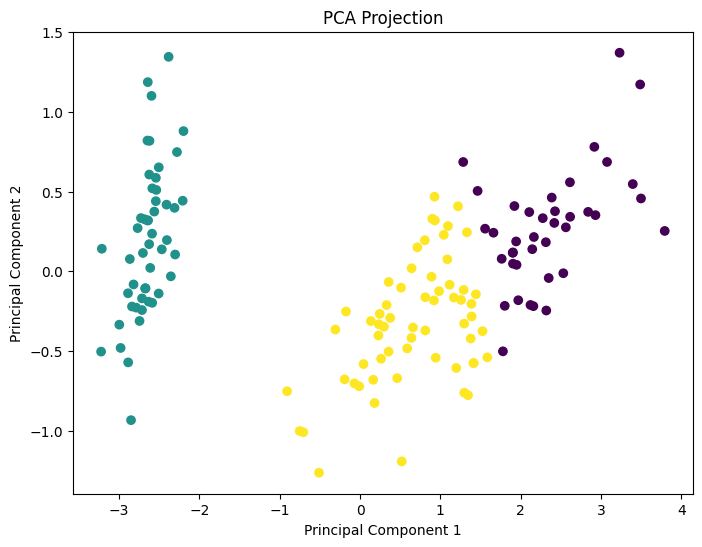

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Projection")

plt.show()

## Explained Variance Ratio

In [18]:
print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.92461621 0.05301557]


## Mini Project – Compare Predicted Clusters with True Labels

In [19]:
comparison = pd.DataFrame({
    "True Label": y,
    "Predicted Cluster": clusters
})

comparison.head(10)

,True Label,Predicted Cluster
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1
7,0,1
8,0,1
9,0,1


In [20]:
print(confusion_matrix(y, clusters))

[[ 0 50  0]
 [ 3  0 47]
 [36  0 14]]


## Observation

The K-Means algorithm grouped the Iris flowers into three clusters. PCA reduced the dataset from four dimensions to two dimensions while preserving most of the important information. The explained variance ratio shows how much variance is retained by the principal components.

## Conclusion

In this notebook:

- Applied K-Means Clustering on the Iris dataset.
- Printed cluster centers.
- Visualized the clusters using Matplotlib.
- Applied PCA to reduce the dataset to two dimensions.
- Calculated the explained variance ratio.
- Compared predicted clusters with the true species labels.

This notebook fulfills the Week 3 assignment requirements of the Machine Learning & AI Internship.